Импорт необходимых библиотек

In [37]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import glob
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

Объединение всех CSV-файлов в один DataFrame

In [38]:
data_path = "../data/channels_data/processed/"

df = pd.concat([pd.read_csv(f) for f in glob.glob(os.path.join(data_path, "*.csv"))], ignore_index=True)

print(f"Размер объединенного датасета: {df.shape}")
df

Размер объединенного датасета: (10763, 85)


,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,16:33:05,2025-11-28 16:33:05+00:00,2025-12-01 02:56:40.802261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,13:46:00,2025-11-28 13:46:00+00:00,2025-12-01 02:56:40.803261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,10:39:40,2025-11-28 10:39:40+00:00,2025-12-01 02:56:40.803261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,09:43:18,2025-11-28 09:43:18+00:00,2025-12-01 02:56:40.803261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,09:38:29,2025-11-28 09:38:29+00:00,2025-12-01 02:56:40.804698,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,tbank_education,Т-Образование,115068,2548,2024-12-02,12:30:57,2024-12-02 12:30:57+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10759,tbank_education,Т-Образование,115068,2547,2024-12-01,13:46:18,2024-12-01 13:46:18+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10760,tbank_education,Т-Образование,115068,2546,2024-12-01,13:45:52,2024-12-01 13:45:52+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10761,tbank_education,Т-Образование,115068,2545,2024-12-01,10:53:46,2024-12-01 10:53:46+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Обработка пропущенных значений (NaN)

In [39]:
missing_data = df.isnull().sum().to_frame(name='Кол-во пропусков')
missing_data['% пропусков'] = (missing_data['Кол-во пропусков'] / len(df)) * 100
missing_data = missing_data[missing_data['Кол-во пропусков'] > 0].sort_values('Кол-во пропусков', ascending=False)

print("Столбцы с пропусками:")
missing_data

Столбцы с пропусками:


,Кол-во пропусков,% пропусков
reaction_🎃,10762,99.990709
reaction_😨,10762,99.990709
reaction_🥱,10762,99.990709
reaction_🙊,10761,99.981418
reaction_🤪,10759,99.962836
...,...,...
reaction_🤔,6005,55.792995
reaction_🔥,4293,39.886649
reaction_👍,1558,14.475518
media_type,1485,13.797268


Удаление пустых столбцов

In [40]:
columns_to_drop = missing_data[missing_data['% пропусков'] == 100].index.tolist()
df = df.drop(columns=columns_to_drop)
print(f"Удалено полностью пустых столбцов: {len(columns_to_drop)}, размер: {df.shape}")

Удалено полностью пустых столбцов: 0, размер: (10763, 85)


Пропуски в реакциях означают, что реакции не ставили, заменяем их на 0

In [41]:
reaction_columns = [col for col in df.columns if col.startswith('reaction_')]
df[reaction_columns] = df[reaction_columns].fillna(0)

print(f"Колонок с реакциями: {len(reaction_columns)}")
df

Колонок с реакциями: 65


,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,16:33:05,2025-11-28 16:33:05+00:00,2025-12-01 02:56:40.802261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,13:46:00,2025-11-28 13:46:00+00:00,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,10:39:40,2025-11-28 10:39:40+00:00,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,09:43:18,2025-11-28 09:43:18+00:00,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,09:38:29,2025-11-28 09:38:29+00:00,2025-12-01 02:56:40.804698,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,tbank_education,Т-Образование,115068,2548,2024-12-02,12:30:57,2024-12-02 12:30:57+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10759,tbank_education,Т-Образование,115068,2547,2024-12-01,13:46:18,2024-12-01 13:46:18+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10760,tbank_education,Т-Образование,115068,2546,2024-12-01,13:45:52,2024-12-01 13:45:52+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10761,tbank_education,Т-Образование,115068,2545,2024-12-01,10:53:46,2024-12-01 10:53:46+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Пропуск в типе медиа означает пост без медиа

In [42]:
df['media_type'] = df['media_type'].fillna('no_media')
print(df['media_type'].unique())

['photo' 'document' 'other' 'no_media']


Функция для постов без текста: у опросов ставим маркер [ОПРОС], остальные удаляем

In [43]:
def process_missing_text_in_dataframe(df):
    """Пост с опросом без текста получает маркер '[ОПРОС]', остальные посты без текста удаляем"""
    df = df.copy()
    missing_text_mask = df['text'].isna() | (df['text'].astype(str).str.strip() == '')
    polls_mask = missing_text_mask & (df['has_poll'] == True)
    to_drop = missing_text_mask & ~polls_mask

    df.loc[polls_mask, 'text'] = '[ОПРОС]'
    df = df[~to_drop].copy()

    print(f"Постов без текста: {missing_text_mask.sum():,} (опросы: {polls_mask.sum():,}, удалено: {to_drop.sum():,})")
    print(f"Осталось постов: {len(df):,}")
    return df

Применяем обработку пропусков в тексте

In [44]:
df = process_missing_text_in_dataframe(df)

Постов без текста: 284 (опросы: 0, удалено: 284)
Осталось постов: 10,479


Проверка текстов после обработки: типы постов и распределение длины

С текстом: 10,479, опросов: 0, пустых: 0
has_poll=True: 120, с маркером [ОПРОС]: 0
count    10479.0
mean       831.0
std        905.0
min          1.0
25%        301.0
50%        472.0
75%       1017.0
max       8278.0
Name: text, dtype: float64


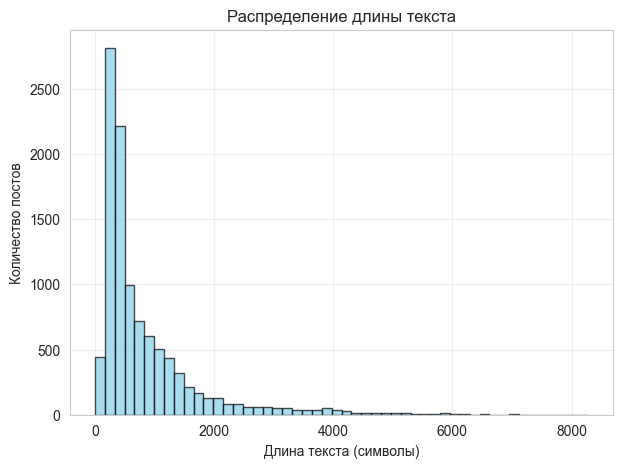

In [45]:
def analyze_text_processing_results(df):
    text_series = df['text'].astype(str)
    poll_marker_count = (text_series == '[ОПРОС]').sum()
    empty_text_count = (text_series.str.strip() == '').sum()
    real_text_mask = (text_series.str.strip() != '') & (text_series != '[ОПРОС]')
    real_text_lengths = text_series[real_text_mask].str.len()

    print(f"С текстом: {real_text_mask.sum():,}, опросов: {poll_marker_count:,}, пустых: {empty_text_count:,}")
    print(f"has_poll=True: {(df['has_poll'] == True).sum():,}, с маркером [ОПРОС]: {poll_marker_count:,}")
    print(real_text_lengths.describe().round(0))

    plt.figure(figsize=(7, 5))
    plt.hist(real_text_lengths, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('Длина текста (символы)')
    plt.ylabel('Количество постов')
    plt.title('Распределение длины текста')
    plt.grid(True, alpha=0.3)
    plt.show()


analyze_text_processing_results(df)

# лишние пробелы
df['text'] = df['text'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)

Определение отложенных постов: они публикуются ровно в 00 секунд

In [46]:
def detect_scheduled_by_seconds(df):
    """Отложенные посты опубликованы ровно в 00 секунд"""
    time_col = 'post_datetime' if 'post_datetime' in df.columns else 'post_time'
    if df[time_col].dtype == 'object':
        df[time_col] = pd.to_datetime(df[time_col])

    by_seconds = df[time_col].dt.second == 0
    print(f"Отложенных по секундам: {by_seconds.sum():,} ({by_seconds.mean():.1%})")

    if 'is_scheduled' in df.columns:
        existing = df['is_scheduled'].astype(str).str.lower().isin(['true', '1', 'yes'])
        match = (existing == by_seconds).mean()
        print(f"Совпадение с is_scheduled: {match:.1%}")
        # если совпадение низкое, существующий столбец не трогаем
        if match > 0.8:
            df['is_scheduled'] = by_seconds
        else:
            df['is_scheduled_seconds'] = by_seconds
    else:
        df['is_scheduled'] = by_seconds
    return df


df = detect_scheduled_by_seconds(df)

Отложенных по секундам: 204 (1.9%)
Совпадение с is_scheduled: 98.8%


Перевод времени публикации из UTC в московское (+3 часа)

In [47]:
def fix_time_simple(df):
    """UTC -> московское время (+3 часа)"""
    df['post_datetime'] = pd.to_datetime(df['post_datetime'], utc=True) + pd.Timedelta(hours=3)
    df['post_datetime'] = df['post_datetime'].dt.tz_localize(None)
    df['post_time'] = df['post_datetime'].dt.time.astype(str)
    df['post_date'] = df['post_datetime'].dt.date.astype(str)
    return df


df = fix_time_simple(df)
df

,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,19:33:05,2025-11-28 19:33:05,2025-12-01 02:56:40.802261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,16:46:00,2025-11-28 16:46:00,2025-12-01 02:56:40.803261,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,13:39:40,2025-11-28 13:39:40,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,12:43:18,2025-11-28 12:43:18,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,12:38:29,2025-11-28 12:38:29,2025-12-01 02:56:40.804698,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10757,tbank_education,Т-Образование,115068,2549,2024-12-03,18:00:00,2024-12-03 18:00:00,2025-12-01 02:59:27.803807,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10758,tbank_education,Т-Образование,115068,2548,2024-12-02,15:30:57,2024-12-02 15:30:57,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10760,tbank_education,Т-Образование,115068,2546,2024-12-01,16:45:52,2024-12-01 16:45:52,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10761,tbank_education,Т-Образование,115068,2545,2024-12-01,13:53:46,2024-12-01 13:53:46,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
df_drop = df.drop(columns=['scraped_at'])

Сохранение очищенного датасета (промежуточная версия)

In [50]:
output_path = "../data/final/cleaned_ai_publics_dataset_DROPPED.csv"
df_drop.to_csv(output_path, index=False, encoding='utf-8-sig')

Загрузка итогового датасета

In [51]:
df = pd.read_csv('../data/final/ai_publics_dataset.csv', encoding='utf-8')
df['post_datetime'] = pd.to_datetime(df['post_datetime'])

df

,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,19:33:05,2025-11-28 19:33:05,2025-12-01 02:56:40.802261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,16:46:00,2025-11-28 16:46:00,2025-12-01 02:56:40.803261,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,13:39:40,2025-11-28 13:39:40,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,12:43:18,2025-11-28 12:43:18,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,12:38:29,2025-11-28 12:38:29,2025-12-01 02:56:40.804698,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10474,tbank_education,Т-Образование,115068,2549,2024-12-03,18:00:00,2024-12-03 18:00:00,2025-12-01 02:59:27.803807,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10475,tbank_education,Т-Образование,115068,2548,2024-12-02,15:30:57,2024-12-02 15:30:57,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10476,tbank_education,Т-Образование,115068,2546,2024-12-01,16:45:52,2024-12-01 16:45:52,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10477,tbank_education,Т-Образование,115068,2545,2024-12-01,13:53:46,2024-12-01 13:53:46,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Объединение кастомных реакций с обычными эмодзи по карте соответствия

In [52]:
# кастомные реакции, которые складываем с обычными эмодзи
REACTION_MAP = {
    'reaction_custom_5370610867094166617': 'reaction_🎃',
    'reaction_custom_5357314052072692864': 'reaction_🤖',
}


def merge_mapped_reactions(df, reaction_map):
    for custom_col, emoji_col in reaction_map.items():
        if custom_col in df.columns and emoji_col in df.columns:
            df[emoji_col] = df[[emoji_col, custom_col]].sum(axis=1, skipna=True)
            df = df.drop(columns=[custom_col])
            print(f"{custom_col} -> {emoji_col}")
    return df


df = merge_mapped_reactions(df, REACTION_MAP)

In [53]:
df_drop = df.drop(columns=['scraped_at'])

Сохранение очищенного датасета

In [54]:
output_path = "../data/final/cleaned_ai_publics_datasetDROP.csv"
df_drop.to_csv(output_path, index=False, encoding='utf-8-sig')

Временные признаки: день недели, час, выходной, часть суток

In [55]:
df['post_day_of_week'] = df['post_datetime'].dt.dayofweek  # 0 - понедельник
df['post_hour'] = df['post_datetime'].dt.hour
df['is_weekend'] = (df['post_day_of_week'] >= 5).astype(int)
df['time_of_day'] = pd.cut(df['post_hour'], bins=[-1, 6, 12, 18, 23],
                           labels=['Ночь', 'Утро', 'День', 'Вечер'])

Признаки текста: длина, вопросы, восклицания, хештеги, упоминания

In [56]:
df['text_length_chars'] = df['text'].apply(len)
df['text_length_words'] = df['text'].apply(lambda x: len(str(x).split()))
df['has_question'] = df['text'].str.contains(r'\?', na=False).astype(int)
df['has_exclamation'] = df['text'].str.contains(r'!', na=False).astype(int)
df['hashtags_count'] = df['text'].str.count(r'#\w+')
df['mentions_count'] = df['text'].str.count(r'@\w+')

Укрупнение типов медиа и dummy-переменные

In [57]:
media_mapping = {
    'no_media': 'none',
    'photo': 'image',
    'video': 'video',
    'gif': 'video',
    'voice': 'audio',
    'audio': 'audio',
    'video_note': 'video',
}
df['media_category'] = df['media_type'].map(media_mapping).fillna('other')

media_dummies = pd.get_dummies(df['media_category'], prefix='media')
df = pd.concat([df, media_dummies], axis=1)

Целевые метрики: engagement rate, вирусность и высокий охват

In [59]:
# Engagement rate = (реакции + репосты) / просмотры
df['engagement_rate'] = (df['total_reactions'] + df['forwards']) / df['views']
df['engagement_rate'] = df['engagement_rate'].replace([np.inf, -np.inf], 0).fillna(0)

# бинарные цели: верхние 10% по ER и по просмотрам
er_threshold = df['engagement_rate'].quantile(0.9)
df['is_viral'] = (df['engagement_rate'] >= er_threshold).astype(int)

views_threshold = df['views'].quantile(0.9)
df['is_high_reach'] = (df['views'] >= views_threshold).astype(int)

Сохранение датасета с новыми признаками

In [60]:
output_path = "../data/final/cleaned_ai_publics_dataset_feature_engineering.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')  # utf-8-sig, чтобы Excel читал кириллицу
print(f"Сохранено: {output_path}")

Сохранено: ../data/final/cleaned_ai_publics_dataset_feature_engineering.csv
